# DevContext AI - Full Agent Capstone Checkpoint

## Problem Statement
Wire production patches into the LangGraph agent and confirm end-to-end behavior on the real FastAPI repo.

## My Approach
 
Split the agent into two separate notebooks - ingestion first, agent second - because the ingestion was a full problem on its own. For the agent, I planned five patches around a LangGraph state machine:
 
1. **Query rewriting** - LLM rewrites vague queries before embedding, with a fallback to raw query if the rewritten one returns zero results
2. **Hybrid retrieval** - BM25 + semantic search fused via RRF, replacing pure cosine similarity
3. **Graceful degradation** - `CONTEXT_EMPTY` sentinel prevents the LLM from hallucinating on zero-result paths
4. **Source-type routing** - PR impact mode searches only the codebase collection; QA mode uses an LLM parallel router to fan out to doc/code/schema as needed
For the graph structure, I used `Annotated[dict, merge_sources]` with a custom reducer to handle parallel fan-out without last-write-wins collisions on the `sources` field.
 
## What I Learned

- **Prompt strictness is a retrieval quality dial.** My first QA prompt said "state strictly that you cannot find the answer" for any weak context match. That caused the agent to refuse answers even when 3 chunks with good RRF scores were present. Loosening it to "synthesize from partial context, only refuse if completely unrelated" fixed it without removing the graceful degradation guard.
- **BM25 doesn't filter by volume — `release-notes.md` dominated.** The doc collection had ~1036 chunks from release notes alone. BM25 naturally ranks high-frequency files higher because they contribute more document mass to the index. The fix is a per-file chunk cap at ingestion time (e.g., max 50 chunks per file), which means re-ingesting. Noted as a future fix.
- **`merge_sources` reducer is the right solution for parallel fan-out.** Without it, parallel nodes writing to the same `sources` key cause last-write-wins — you lose results from all but one branch. `Annotated[dict, merge_sources]` makes LangGraph call the reducer instead of overwriting.
- **The rewritten query can be too specific.** A query rewriter that outputs exact function names sometimes generates phrasing that doesn't appear verbatim in any chunk. The retry-with-raw-query fallback (via `prepare_raw_query_fallback` → `llm_parallel_router_node`) handles this: attempt 1 uses the rewritten query, attempt 2 uses the original. `retry_attempt` in state tracks which attempt we're on.
 
## Where I Got Stuck
 
The hardest part of this sprint wasn't the code — it was debugging why the agent was returning "Cannot find the answer" even when the logs showed 3 chunks retrieved with RRF scores above the threshold.

Combined: good RRF scores, correct chunk count in logs, but garbage context reaching the LLM. The prompt's strictness then turned that garbage context into a refusal. Three separate bugs conspiring to produce the same symptom.

## What I'd Do Differently
 
- **Add a `source_type` field to metadata at ingestion time.** This was missed in the first ingestion pass. The PR impact filter (`where={"source_type": "python"}`) depends on it — without it the filter returns zero results. Fixing this requires re-ingesting, which is planned.
- **Cap chunks per file at ingestion.** `release-notes.md` with 1036 chunks dominates BM25 scoring for any query containing common version words. A 50-chunk-per-file cap at walk time would prevent one file from flooding the index.
- **Always restart kernel before final test run.** Jupyter's kernel memory makes it easy to run a working-looking agent on stale function definitions. A full restart + run-all is the only way to verify the code as written actually works.
- **Wire the ingestion blocklist test explicitly.** The blocklist logic (`is_blocked`, `fnmatch`) was planned as patch but ended up implemented in the ingestion notebook rather than tested in the agent notebook. It should have a dedicated test cell here with `staging.env`, `db_credentials.json` as explicit test cases.

In [3]:

from dotenv import load_dotenv
import os
import requests
import numpy as np
from rank_bm25 import BM25Okapi 
from huggingface_hub import login
import chromadb
import logging
import json
import time
from typing import TypedDict
from langgraph.graph import StateGraph, START , END
from langchain_groq import ChatGroq
import re
from typing import TypedDict, Annotated, List, Optional
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import MemorySaver
from langchain_groq import ChatGroq
llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0)

load_dotenv()

HF_TOKEN = os.getenv("HUGGING_FACE_API_KEY")
model_ids = {
    "MPNet_doc_sql": "sentence-transformers/all-mpnet-base-v2"
    ,"baai_code":"BAAI/bge-base-en-v1.5"
}

cwd = os.getcwd()
db_path = os.path.abspath(os.path.join(cwd, "..", "chroma_db"))
client_chromadb = chromadb.PersistentClient(path=db_path)


# Set up structured logging - forces everything onto clean single lines
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s %(levelname)s %(message)s'
)
logger = logging.getLogger("agent_debug")

d:\Python\genai-engineering-portfolio\venv\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [81]:
#Embedding with retry 
def get_api_embeddings(texts: list, model_id: str) -> list | None:
    if not texts:
        return []
    api_url = f"https://router.huggingface.co/hf-inference/models/{model_id}/pipeline/feature-extraction"
    headers = {"Authorization": f"Bearer {HF_TOKEN}"}
    payload = {"inputs": texts, "options": {"wait_for_model": True}}

    for attempt in range(3):
        try:
            response = requests.post(api_url, headers=headers, json=payload, timeout=60)
            if response.status_code == 200:
                arr = np.array(response.json())
                if arr.ndim == 3:
                    arr = arr.mean(axis=1)
                return arr.tolist()
            elif response.status_code == 503:
                wait = 15 * (attempt + 1)
                print(f" HF model loading — retrying in {wait}s (attempt {attempt+1}/3)...")
                time.sleep(wait)
            else:
                print(f"HTTP {response.status_code}: {response.text[:300]}")
                return None
        except requests.exceptions.Timeout:
            print(f"Timeout on attempt {attempt+1} — retrying...")
            time.sleep(5)
        except Exception as e:
            print(f"Unexpected error: {e}")
            return None
    print("All 3 attempts failed — sub-batch dropped")
    return None


In [108]:
# A local dictionary reducer
def merge_sources(left: dict, right: dict) -> dict:
    merged = left.copy() if left else {}
    for category, new_results in (right or {}).items():
        if category in merged and isinstance(merged[category], list):
            merged[category] = merged[category] + new_results
        else:
            merged[category] = new_results
    return merged

class AgentState(TypedDict):
    raw_query : str         # "user query"
    query: str              # "rewritten query"
    mode: str               # "qa" or "impact"
    sub_mode: list[str]     # "code_base" , "doc" , "schema" - for "QA"
    retrieved_context: str  # "docs/code chunks retrieved from ChromaDB"
    answer: str             # llm answer
    sources: Annotated[dict, merge_sources]  # "Sources retrieved from chromadb" &  merge_sources : "Merges parallel dictionaries cleanly" 
    sources_cited : list[str] #Explicit list tracking for citations
    changed_functions: list[str] # extracted from PR diff
    impacted_files: list[str]   # files that call changed functions
    high_confidence_callers: list[dict]
    uncertain_candidates: list[dict]
    user_approval: Optional[str]
    retry_attempt: int

def empty_state(query: str) -> AgentState:
    """Always initialise ALL keys - prevents KeyError in any node."""
    return {
        "raw_query":query , "query": '', "mode": "","sub_mode": [], "retrieved_context": "",
        "answer": "", "sources": {}, "sources_cited":[],  "changed_functions": [],
        "impacted_files": [], "high_confidence_callers": [],
        "uncertain_candidates": [], "user_approval": None,
        "retry_attempt":0
    }

In [109]:
#entry node
def rewrite_user_query(state: AgentState)->dict :
    prompt = f"""
    You are an expert query optimization agent for a software repository hybrid RAG system.
    Your task is to take a raw developer query and rewrite it to maximize search accuracy across codebase, database schemas, and documentation.

    Rules:
    1. If the query is high-level/exploratory (e.g., "what does this repo do?", "how to setup"), preserve the descriptive intent. Do NOT turn it into a code syntax or SQL query. Include keywords likely found in READMEs or architectural docs.
    2. If the query is technical (e.g., looking for a function or database column), include relevant code keywords, common naming conventions, or structural terms.
    3. Remove conversational filler, punctuation, and greeting words.
    4. Respond ONLY with the final optimized search query string. No explanations, markdown formatting, or backticks.
    5. Keep the rewritten query under 8 words. Do not produce a list of nouns - write a natural phrase.
    Raw Query: {state['raw_query']}
    Optimized Query:
    """
    response = llm.invoke(prompt)
    query=response.content.strip().lower()
    
    logger.info(json.dumps({
        "node": "rewrite_user_query",
        "event": "rewrite_query",
        "raw_query_preview": state["raw_query"][:60]
    }))
    return {"query":query}

def route_intent(state: AgentState) -> dict :
    prompt = f"""
    Classify below query into qa or pr_impact .
    qa=asking about how code/system works or onboarding questions
    pr_impact=asking about what code breaks if code changes are done , pr review questions.
    Query = {state['query']}
    Respond with one word only : qa or pr_impact.
    """
    response = llm.invoke(prompt , max_tokens=5)
    mode=response.content.strip().lower()
    if mode not in ('qa','pr_impact'):
        mode='qa' #fallback
    
    logger.info(json.dumps({
        "node": "route_intent",
        "event": "intent_classification",
        "query_preview": state["query"][:60],
        "classified_mode": mode
    }))
    return {"mode":mode}

#Mapping intent 
def intent_router(state: AgentState) -> str:
    logger.info(json.dumps({
        "edge": "intent_router",
        "mode": state["mode"]
    }))
    return state["mode"]  # "qa" -> qa branch, "pr_impact" ->  pr branch 


In [110]:
def get_collection_safely(client, name):
    existing_collections = [c.name for c in client.list_collections()]
    
    if name not in existing_collections:
        raise ValueError(f"Collection '{name}' does not exist.")
        
    return client.get_collection(name)

# Usage
try:
    collection_doc = get_collection_safely(client_chromadb, "docbase_fastapi")
    collection_schema = get_collection_safely(client_chromadb, "schemabase_fastapi")
    collection_code = get_collection_safely(client_chromadb, "codebase_fastapi")
except ValueError as e:
    print(e)

In [111]:
print(f"Count of chunks in Document base : {collection_doc.count()}")
print(f"Count of chunks in Code base : {collection_code.count()}")
print(f"Count of chunks in Schema base : {collection_schema.count()}")


Count of chunks in Document base : 1388
Count of chunks in Code base : 222
Count of chunks in Schema base : 16


In [112]:
def get_bm25 (collection) :
    all_data_doc = collection.get()
    documents = all_data_doc["documents"]
    metadatas = all_data_doc["metadatas"]
    ids = all_data_doc["ids"]

    tokenized = [re.findall(r"\b\w+\b", doc.lower()) for doc in documents]
    bm25 =  BM25Okapi(tokenized)

    mapping = {
        "documents":documents , "metadatas": metadatas , "ids" : ids
    }
    return bm25 , mapping

bm25_code , mapping_code = get_bm25(collection_code)
bm25_doc , mapping_doc = get_bm25(collection_doc)
bm25_schema , mapping_schema = get_bm25(collection_schema)

In [113]:
MIN_SCORE_RRF=0.010
def bm25_search (bm_25 , query : str , mapping : dict , top_n: int = 3) -> list :
    tokenized_query = re.findall(r"\b\w+\b", query.lower())
    scores = bm_25.get_scores(tokenized_query)
    top_indices = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)[:top_n]
    bm25_results = []
    for idx in top_indices:
        bm25_results.append({
            "id": mapping["ids"][idx],
            "text": mapping["documents"][idx],
            "metadata": mapping["metadatas"][idx] or {}
        })

    return bm25_results

def semantic_search (collection : chromadb.Collection , embedding_model :str, query : str , top_n: int = 3) -> list :
    query_vec_embedding = get_api_embeddings(query,embedding_model)
    res = collection.query(query_embeddings=[query_vec_embedding], n_results=top_n)
    semantic_results=[]
    if res["documents"] :
        for i in range(len(res["documents"][0])):
            semantic_results.append({
                "id": res["ids"][0][i],
                "text": res["documents"][0][i],
                "metadata": res["metadatas"][0][i] or {}
            })
    
    return semantic_results

def rrf_fusion(bm25_results: list, semantic_results: list, k: int = 60, top_n: int = 3):
    fused_scores = {}
    
    def add_ranks(results):
        for rank, doc in enumerate(results):
            # Use the document text or a unique ID as the key
            doc_id = doc["id"]
            if doc_id not in fused_scores:
                fused_scores[doc_id] = {"doc": doc, "score": 0.0}
            # RRF Formula: 1 / (k + rank)
            fused_scores[doc_id]["score"] += 1.0 / (k + rank + 1)

    add_ranks(bm25_results)
    add_ranks(semantic_results)
    
    reranked = sorted(fused_scores.values(), key=lambda x: x["score"], reverse=True)
    fused_results = []
    for item in reranked[:top_n]:
        score=round(item["score"] , 4)
        if score >= MIN_SCORE_RRF:
            doc_copy = item["doc"].copy()
            doc_copy["rrf_score"] = round(item["score"], 4) # Rounding keeps logs clean
            fused_results.append(doc_copy)
        else :
            continue
        
    return fused_results

In [114]:
def llm_parallel_router_node(state: AgentState) -> dict:
    """
    Uses the LLM to select MULTIPLE target collections to search simultaneously.
    """
    prompt = f"""
    You are an expert search routing agent for a software repository RAG system.
    Analyze the user query and determine which collections must be searched to fully answer it. 
    You can select one, two, or all three options.
    
    Categories to choose from:
    - "codebase": For questions about syntax, function implementations, classes, or code logic.
    - "schema": For questions about database tables, columns, constraints, or SQL schemas.
    - "doc": For questions about architecture, high-level features, setup instructions, or how-to flows.
    
    Query: "{state['query']}"
    
    Respond ONLY with a JSON object containing a "targets" key mapped to a list of selected strings.
    Do not include markdown blocks, backticks, or conversational filler.
    
    Example response for an exploratory question: 
    {{"targets": ["doc", "codebase", "schema"]}}
    """
    response = llm.invoke(prompt, max_tokens=30)
    clean_content = response.content.strip()

    try:
        targets = json.loads(clean_content).get("targets", ["doc"])
    except Exception:
        targets = []
        if "code" in clean_content.lower(): targets.append("codebase")
        if "schema" in clean_content.lower(): targets.append("schema")
        if "doc" in clean_content.lower(): targets.append("doc")
        if not targets: targets = ["doc"] # Default safe fallback

    logger.info(json.dumps({
        "node": "llm_parallel_router_node",
        "event": "parallel_target_selection",
        "selected_sub_modes": targets
    }))    
    return {"sub_mode": targets} 

def prepare_raw_query_fallback(state: AgentState) -> dict:
    logger.warning(json.dumps({
        "node": "prepare_raw_query_fallback",
        "event": "trigger_fallback_retry",
        "falling_back_to": state["raw_query"]
    }))
    return {
        "query": state["raw_query"],
        "retry_attempt": state["retry_attempt"] + 1,
        "sub_mode": ["doc", "codebase", "schema"],
        "sources": {"doc": [], "codebase": [], "schema": []}  
    }

def check_context_router(state: AgentState) -> str:
    logger.info(json.dumps({
        "edge": "check_context_router",
        "context_preview": state["retrieved_context"][:100],
        "retry_attempt": state["retry_attempt"],
        "sources_keys": list(state.get("sources", {}).keys()),
        "sources_lengths": {k: len(v) for k, v in state.get("sources", {}).items()}
    }))
    if "CONTEXT_EMPTY" in state["retrieved_context"] and state["retry_attempt"] == 0:
        logger.info(json.dumps({
            "edge": "check_context_router",
            "decision": "empty_detected_routing_to_fallback"
        }))
        return "fallback"
    
    # Otherwise, move forward to generate an answer (either we have data, or it's attempt #2)
    logger.info(json.dumps({
        "edge": "check_context_router",
        "decision": "proceeding_to_generation"
    }))
    return "generate"

def get_search_nodes(state: AgentState) -> list[str]:
    # Since state["sub_mode"] is a list, e.g., ["codebase", "schema"]
    # mapping those strings directly to actual graph node names.
    nodes = []
    if "codebase" in state["sub_mode"]:
        nodes.append("search_codebase")
    if "schema" in state["sub_mode"]:
        nodes.append("search_schema")
    if "doc" in state["sub_mode"]:
        nodes.append("search_docs")

    logger.info(json.dumps({
        "edge": "get_search_nodes",
        "event": "fan_out_trigger",
        "active_parallel_nodes": nodes
    }))    
    # Safe fallback if the list is empty
    return nodes if nodes else ["search_docs"]

In [115]:
#QA node
# Helper to make database matches safe and compressed for JSON log dumps
def format_log_chunks(rrf_results: list) -> list:
    return [
        {
            "id": r.get("id", "unknown"),
            "rrf_score": r.get("rrf_score", 0.0),
            "text_snippet": r.get("text", "")[:80] + "...",
            "file": (r.get("metadata") or {}).get("file_name", "unknown") 
        }
        for r in rrf_results
    ]

def search_codebase(state : AgentState) -> dict:
    """Search the codebase index for functions, classes, and callers. Use for code-related questions."""
    bm25_res=bm25_search(bm25_code , state["query"] , mapping_code )
    semantic_res=semantic_search(collection_code , model_ids["baai_code"] , state["query"] )
    rrf = rrf_fusion(bm25_res , semantic_res )

    logger.info(json.dumps({
        "node": "search_codebase",
        "event": "database_retrieval",
        "chunks_found": len(rrf),
        "matches": format_log_chunks(rrf)
    }))

    return {"sources": {"codebase": rrf}}

def search_docs(state : AgentState) -> dict:
    """Search internal documentation and README files. Use for how-to and architecture questions."""
    bm25_res=bm25_search(bm25_doc , state["query"] , mapping_doc )
    semantic_res=semantic_search(collection_doc , model_ids["MPNet_doc_sql"] , state["query"] )
    rrf = rrf_fusion(bm25_res , semantic_res )

    logger.info(json.dumps({
        "node": "search_docs",
        "event": "database_retrieval",
        "chunks_found": len(rrf),
        "matches": format_log_chunks(rrf)
    }))

    return {"sources": {"doc": rrf}} 


def search_schema(state: AgentState) -> dict:
    """Search schema for tables , columns , Sps , triggers etc. Use for data base related questions"""
    bm25_res=bm25_search(bm25_schema , state["query"] , mapping_schema )
    semantic_res=semantic_search(collection_schema , model_ids["MPNet_doc_sql"] , state["query"] )
    rrf = rrf_fusion(bm25_res , semantic_res )

    logger.info(json.dumps({
        "node": "search_schema",
        "event": "database_retrieval",
        "chunks_found": len(rrf),
        "matches": format_log_chunks(rrf)
    }))
    return {"sources": {"schema": rrf}}  


def aggregate_search_res(state: AgentState) -> dict:
    """
    Gathers contexts collected simultaneously across whichever categories executed.
    """
    context_chunks = []
    sources = state.get("sources", {})
    keys_found = []

    if "codebase" in sources and sources["codebase"]:
        code_str = "\n".join([s["text"] for s in sources["codebase"] if "text" in s])
        if code_str.strip():
            context_chunks.append(f"=== RELEVANT CODE SNIPPETS ===\n{code_str}")
            keys_found.append("codebase")

    if "schema" in sources and sources["schema"]:
        schema_str = "\n".join([s["text"] for s in sources["schema"] if "text" in s])
        if schema_str.strip():
            context_chunks.append(f"=== DATABASE SCHEMAS ===\n{schema_str}")
            keys_found.append("schema")

    if "doc" in sources and sources["doc"]:
        doc_str = "\n".join([s["text"] for s in sources["doc"] if "text" in s])
        if doc_str.strip():
            context_chunks.append(f"=== DOCUMENTATION ===\n{doc_str}")
            keys_found.append("doc")

    combined_context = (
        "\n\n".join(context_chunks) if context_chunks
        else "CONTEXT_EMPTY: No documents matched with sufficient confidence."
    )

    logger.info(json.dumps({
        "node": "aggregate_search_res",
        "event": "context_consolidation",
        "total_payload_characters": len(combined_context),
        "keys_merged": keys_found   
    }))
    return {"retrieved_context": combined_context}

#QA answer generate 
def qa_retrieve_generate(state: AgentState) -> dict:

    prompt = (
        "You are a codebase assistant. Answer using ONLY the context below.\n"
        "If the context contains partial or indirect information, synthesize the best possible answer from it.\n"  #changed
        "Only say you cannot answer if the context is completely unrelated to the query.\n"  #changed
        "Cite source keys used (e.g. codebase:authenticate_user, docs:auth-flow.md).\n\n"
        f"Context: {state['retrieved_context']}\n\n"
        f"Query: {state['query']}\n\n"
        "Output format (two lines only):\n"
        "Sources: comma-separated source keys\n"
        "Answer: your answer"
    )
    response = llm.invoke(prompt)
    content = response.content.strip()

    sources, answer = [], content
    for line in content.splitlines():
        if line.lower().startswith("sources:"):
            sources = [s.strip() for s in line.split(":", 1)[1].split(",")]
        elif line.lower().startswith("answer:"):
            answer = line.split(":", 1)[1].strip()

    logger.info(json.dumps({
        "node": "qa_retrieve_generate",
        "event": "token_generation_complete",
        "sources_cited": sources
    }))
    
    return {
        "answer": answer
        ,"sources_cited" : sources
    }

In [ ]:
#pr impact code.
CONFIDENCE_THRESHOLD = 0.025  

def diff_parser (state : AgentState) -> dict:
    pattern = r'^[+-][\t ]*def\s+(\w+)\s*\('
    matches=re.findall(pattern , state['query'] , re.MULTILINE)

    logger.info(json.dumps({
        "node": "diff_parser",
        "event": "regex_diff_extraction",
        "functions_extracted": list(set(matches))
    }))

    return {"changed_functions" :list(set(matches))}

def dependency_finder(state: AgentState) -> dict:
    changed_fns = state.get("changed_functions", [])
    
    # Short-circuit if no functions were successfully parsed from the diff
    if not changed_fns:
        return {
            "retrieved_context": "No code changes detected in the PR query.",
            "impacted_files": [],
            "high_confidence_callers": [],
            "uncertain_candidates": [],
        }

    high_confidence = []
    uncertain = []
    context_chunks = []
    seen_chunks = set() # Prevent evaluating the exact same database chunk twice

    for fn_name in changed_fns:
        bm25_res = bm25_search(bm25_code, fn_name, mapping_code, top_n=5)
        semantic_res = semantic_search(collection_code, model_ids["baai_code"], fn_name, top_n=5)
        fused_matches = rrf_fusion(bm25_res, semantic_res, top_n=5)
        
        for match in fused_matches:
            chunk_id = match["id"]
            if chunk_id in seen_chunks:
                continue
            seen_chunks.add(chunk_id)
            
            meta = match["metadata"] or {}
            file_name = meta.get("file_name") or "unknown_file.py"
            matched_scope = "module_level" 
            clean_text = match["text"].replace(" ", "")
            is_explicit_call = f"{fn_name.strip()}(" in clean_text
            confidence_score = 0.05 if is_explicit_call else 0.01
            
            candidate = {
                "file": file_name,
                "function": f"{matched_scope} (ID: {chunk_id})",
                "score": confidence_score
            }
            
            context_chunks.append(f" File: {file_name} (Chunk ID: {chunk_id}) \n{match['text']}")
            if confidence_score >= CONFIDENCE_THRESHOLD:
                high_confidence.append(candidate)
            else:
                uncertain.append(candidate)

    logger.info(json.dumps({
        "node": "dependency_finder",
        "event": "dependency_analysis",
        "high_confidence_count": len(high_confidence),
        "uncertain_count": len(uncertain)
    }))

    return {
        "retrieved_context": "\n\n".join(context_chunks),
        "impacted_files": list(set([c["file"] for c in high_confidence])), # Unique file list
        "high_confidence_callers": high_confidence,
        "uncertain_candidates": uncertain,
    }

def find_callers(state: AgentState) -> dict:
    uncertain = state.get("uncertain_candidates", [])

    # Pass-through if nothing uncertain or already resolved
    if not uncertain or state.get("user_approval") is not None:
        return {}

    high_conf = state.get("high_confidence_callers", [])

    decision = interrupt({
        "message": "INTERRUPT - Low-confidence match(es) detected",
        "candidates": uncertain,
        "current_high_confidence": high_conf,
        "threshold": CONFIDENCE_THRESHOLD,
    })
    logger.info(json.dumps({
        "node": "find_callers",
        "event": "runtime_resume",
        "user_input_received": decision
    }))
    return {"user_approval": decision}

def impact_generate(state: AgentState) -> dict:
    final_list = list(state.get("high_confidence_callers", []))
    decision = state.get("user_approval", "n")

    if decision and decision.strip().lower() == "y":
        final_list.extend(state.get("uncertain_candidates", []))

    uncertain = state.get("uncertain_candidates", [])
    report_lines = ["\n=== Final PR Impact Report ==="]
    for c in final_list:
        report_lines.append(f"{c['file']}  -  {c['function']}  (score: {c['score']})")
    if decision and decision.strip().lower() == "n":
        for c in uncertain:
            report_lines.append(f"{c['file']}  -  dropped by engineer  (score: {c['score']})")
    report_lines.append("==============================")

    prompt = (
        "You are a code impact analyst. Explain what could break and why, "
        "grounded in the context and confirmed files only. Two sentences per file max.\n\n"
        f"Context:\n{state['retrieved_context']}\n\n"
        f"Confirmed impacted files: {[c['file'] for c in final_list]}"
    )
    response = llm.invoke(prompt)

    logger.info(json.dumps({
        "node": "impact_generate",
        "event": "pipeline_complete",
        "final_impacted_file_count": len(final_list)
    }))

    return {
        "impacted_files": [c["file"] for c in final_list],
        "answer": "\n".join(report_lines) + "\n\n" + response.content,
    }

In [117]:
memory = MemorySaver()
graph = StateGraph(AgentState)
graph.add_node('rewrite_user_query' , rewrite_user_query)
graph.add_node('route_intent' , route_intent)

graph.add_node("prepare_raw_query_fallback", prepare_raw_query_fallback)
graph.add_node("llm_parallel_router_node", llm_parallel_router_node)
graph.add_node("search_codebase", search_codebase)
graph.add_node("search_docs", search_docs)
graph.add_node("search_schema", search_schema)
graph.add_node("aggregate_search_res", aggregate_search_res)
graph.add_node('qa_retrieve_generate' , qa_retrieve_generate)

graph.add_node('diff_parser' , diff_parser)
graph.add_node('dependency_finder' , dependency_finder)
graph.add_node("find_callers", find_callers) 
graph.add_node('impact_generate' , impact_generate)

graph.add_edge(START, 'rewrite_user_query')
graph.add_edge('rewrite_user_query', 'route_intent')
graph.add_conditional_edges('route_intent' , intent_router , 
{
        "qa": "llm_parallel_router_node", 
        "pr_impact": "diff_parser"
})
graph.add_conditional_edges("llm_parallel_router_node",
    get_search_nodes,
    {
        "search_codebase": "search_codebase",
        "search_schema": "search_schema",
        "search_docs": "search_docs"
    }
)
graph.add_edge('search_codebase' , 'aggregate_search_res')
graph.add_edge('search_schema' , 'aggregate_search_res')
graph.add_edge('search_docs' , 'aggregate_search_res')
# graph.add_edge('aggregate_search_res' , 'qa_retrieve_generate')
graph.add_conditional_edges(
    "aggregate_search_res",
    check_context_router,
    {
        "fallback": "prepare_raw_query_fallback",
        "generate": "qa_retrieve_generate"
    }
)
graph.add_edge("prepare_raw_query_fallback", "llm_parallel_router_node")
# graph.add_conditional_edges(
#     "prepare_raw_query_fallback",
#     get_search_nodes,
#     {
#         "search_codebase": "search_codebase",
#         "search_schema": "search_schema",
#         "search_docs": "search_docs"
#     }
# )
graph.add_edge('qa_retrieve_generate' , END)

graph.add_edge('diff_parser' , 'dependency_finder')
graph.add_edge('dependency_finder' , 'find_callers')
graph.add_edge('find_callers' , 'impact_generate')
graph.add_edge('impact_generate' , END)

app=graph.compile(checkpointer=memory)


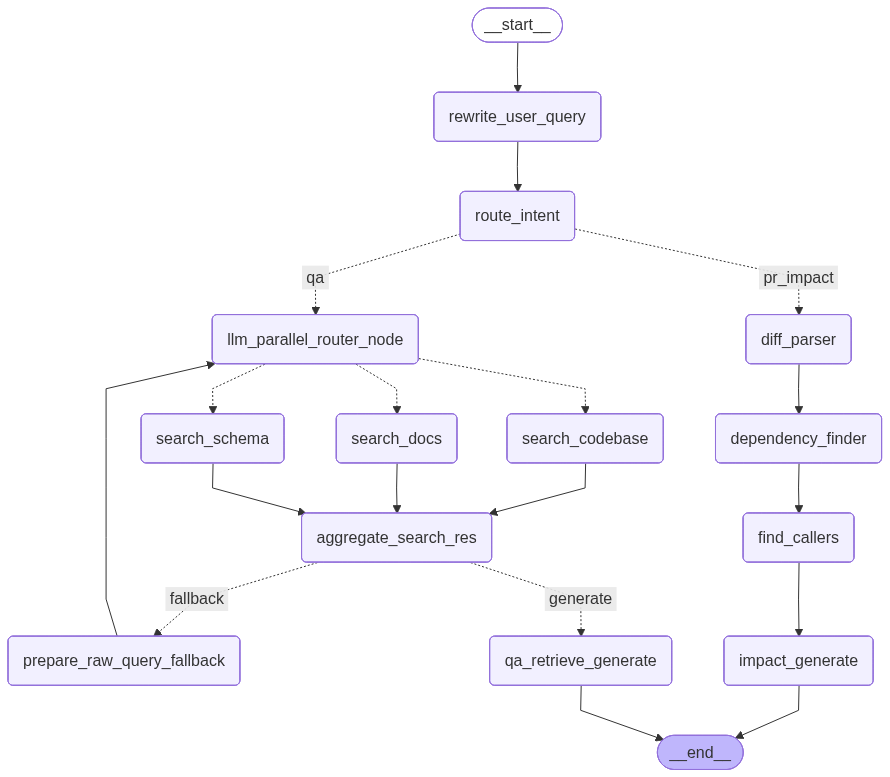

In [118]:
from IPython.display import Image, display

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Could not render PNG safely: {e}")
    print("Fallback: Try Option 2 below for an HTML visualization.")

In [119]:
evaluation_results = {}
query = "What does this repo do?"
logger.info("Starting DevContext AI Stress-Testing Protocol...")
state = empty_state(query)
state["sources"] = {}  
    
print(f"USER QUERY:\n{query}")
print(f"Start time:{time.time()}\n")

config = {"configurable": {"thread_id": f"stress_thread_{int(time.time())}"}}
  
try:
        app.invoke(state, config)
        
        final_state = app.get_state(config).values
        evaluation_results[0] = {
            "mode_chosen": final_state.get("mode"),
            "sub_modes_triggered": final_state.get("sub_mode"),
            "sources_found": list(final_state.get("sources", {}).keys()),
            "agent_response": final_state.get("answer")
        }
        agent_answer = final_state.get("answer", "No response text generated.")
        
except Exception as e:
        if "interrupt" in str(e).lower() or "Command" in str(type(e)):
            logger.warning(f"Case caught by human gate. Resuming with negative ('n') clearance.")
            
            app.invoke(Command(resume="n"), config)
            final_state = app.get_state(config).values
            
            evaluation_results[0] = {
                "mode_chosen": final_state.get("mode"),
                "sub_modes_triggered": final_state.get("sub_mode"),
                "sources_found": list(final_state.get("sources", {}).keys()),
                "agent_response": final_state.get("answer") + " (Halted & Rejected via Interrupt)"
            }
            agent_answer = final_state.get("answer", "") + "\n (Halted: Dropped via Interrupt Node Decision)"
        else:
            logger.error(f"Execution failed on case : {str(e)}")
            evaluation_results[0] = {
                "mode_chosen": "CRASHED",
                "sub_modes_triggered": [],
                "sources_found": [],
                "agent_response": f"Runtime Error: {str(e)}"
            }
            agent_answer = f"PIPELINE CRASHED: {str(e)}"
            final_state = {}

print(f"AGENT ANSWER:\n{agent_answer}")
print(f"End time:{time.time()}\n")

print("=" * 60)        
# brief cooling period for llm for rpd/rpm restrictions
time.sleep(2)

2026-05-21 00:18:40,100 INFO Starting DevContext AI Stress-Testing Protocol...


USER QUERY:
What does this repo do?
Start time:1779302920.1045556



2026-05-21 00:18:40,503 INFO HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
2026-05-21 00:18:40,506 INFO {"node": "rewrite_user_query", "event": "rewrite_query", "raw_query_preview": "What does this repo do?"}
2026-05-21 00:18:40,747 INFO HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
2026-05-21 00:18:40,749 INFO {"node": "route_intent", "event": "intent_classification", "query_preview": "repository purpose and overview", "classified_mode": "qa"}
2026-05-21 00:18:40,754 INFO {"edge": "intent_router", "mode": "qa"}
2026-05-21 00:18:41,302 INFO HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
2026-05-21 00:18:41,307 INFO {"node": "llm_parallel_router_node", "event": "parallel_target_selection", "selected_sub_modes": ["doc"]}
2026-05-21 00:18:41,311 INFO {"edge": "get_search_nodes", "event": "fan_out_trigger", "active_parallel_nodes": ["search_docs"]}
2026-05-21 00:18:42,042 INF

AGENT ANSWER:
The FastAPI repository is managed and maintained by a team with different levels of involvement and permissions, with the goal of supporting the community and maintaining the repository.
End time:1779302922.8383956



In [120]:
test_queries = [
    "How does FastAPI handle dependency injection?",
    "How is the APIRouter class implemented?",
    "How do I add authentication to a FastAPI route?",
    "+def get_current_user(token: str):\n-def get_current_user(token: str, db: Session):",
    "what happens if I remove the middleware stack?"
]

evaluation_results = {}
latencies = []

logger.info("Starting DevContext AI Latency Benchmark...")

for i, query in enumerate(test_queries):
    state = empty_state(query)
    state["sources"] = {}
    config = {"configurable": {"thread_id": f"bench_thread_{i}_{int(time.time())}"}}

    print(f"USER QUERY [{i+1}/5]:\n{query}")
    t0 = time.time()
    print(f"Start time: {t0}\n")

    try:
        app.invoke(state, config)
        final_state = app.get_state(config).values
        evaluation_results[i] = {
            "mode_chosen": final_state.get("mode"),
            "sub_modes_triggered": final_state.get("sub_mode"),
            "sources_found": list(final_state.get("sources", {}).keys()),
            "agent_response": final_state.get("answer")
        }
        agent_answer = final_state.get("answer", "No response text generated.")

    except Exception as e:
        if "interrupt" in str(e).lower() or "Command" in str(type(e)):
            logger.warning(f"Case {i+1} caught by human gate. Resuming with negative ('n') clearance.")
            app.invoke(Command(resume="n"), config)
            final_state = app.get_state(config).values
            evaluation_results[i] = {
                "mode_chosen": final_state.get("mode"),
                "sub_modes_triggered": final_state.get("sub_mode"),
                "sources_found": list(final_state.get("sources", {}).keys()),
                "agent_response": final_state.get("answer") + " (Halted & Rejected via Interrupt)"
            }
            agent_answer = final_state.get("answer", "") + "\n (Halted: Dropped via Interrupt Node Decision)"
        else:
            logger.error(f"Execution failed on case {i+1}: {str(e)}")
            evaluation_results[i] = {
                "mode_chosen": "CRASHED",
                "sub_modes_triggered": [],
                "sources_found": [],
                "agent_response": f"Runtime Error: {str(e)}"
            }
            agent_answer = f"PIPELINE CRASHED: {str(e)}"
            final_state = {}

    elapsed = round(time.time() - t0, 2)
    latencies.append(elapsed)

    print(f"AGENT ANSWER:\n{agent_answer}")
    print(f"End time: {time.time()} | Latency: {elapsed}s\n")
    print("=" * 60)
    time.sleep(2)  # Groq RPM guard

# Latency summary
p50 = round(float(np.percentile(latencies, 50)), 2)
p95 = round(float(np.percentile(latencies, 95)), 2)

print("\n=== LATENCY SUMMARY ===")
print(f"{'#':<4} {'Query':<55} {'Latency':>8}")
for i, (q, l) in enumerate(zip(test_queries, latencies)):
    print(f"Q{i+1:<3} {q[:55]:<55} {l:>7}s")
print(f"\np50: {p50}s  |  p95: {p95}s")

2026-05-21 00:37:37,720 INFO Starting DevContext AI Latency Benchmark...


USER QUERY [1/5]:
How does FastAPI handle dependency injection?
Start time: 1779304057.7492187



2026-05-21 00:37:39,108 INFO HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
2026-05-21 00:37:39,183 INFO {"node": "rewrite_user_query", "event": "rewrite_query", "raw_query_preview": "How does FastAPI handle dependency injection?"}
2026-05-21 00:37:39,440 INFO HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
2026-05-21 00:37:39,442 INFO {"node": "route_intent", "event": "intent_classification", "query_preview": "fastapi dependency injection mechanism", "classified_mode": "qa"}
2026-05-21 00:37:39,447 INFO {"edge": "intent_router", "mode": "qa"}
2026-05-21 00:37:39,692 INFO HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
2026-05-21 00:37:39,700 INFO {"node": "llm_parallel_router_node", "event": "parallel_target_selection", "selected_sub_modes": ["codebase", "doc"]}
2026-05-21 00:37:39,702 INFO {"edge": "get_search_nodes", "event": "fan_out_trigger", "active_parallel_nodes": ["s

AGENT ANSWER:
FastAPI includes an extremely easy to use, but extremely powerful Dependency Injection system, which can be applied at the router level via dependencies=[Depends(...)] or used with yield and scope for more complex logic.
End time: 1779304062.4162939 | Latency: 4.67s



2026-05-21 00:37:44,606 INFO HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
2026-05-21 00:37:44,612 INFO {"node": "rewrite_user_query", "event": "rewrite_query", "raw_query_preview": "How is the APIRouter class implemented?"}


...

AGENT ANSWER:
To set up route authentication in FastAPI, use the `dependencies` parameter in the `include_router` function to apply dependencies to all path operations in a router, and the `callbacks` parameter to apply OpenAPI callbacks.
End time: 1779304072.5170834 | Latency: 3.77s

USER QUERY [4/5]:
+def get_current_user(token: str):
-def get_current_user(token: str, db: Session):
Start time: 1779304074.5212846



2026-05-21 00:37:55,058 INFO HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
2026-05-21 00:37:55,067 INFO {"node": "rewrite_user_query", "event": "rewrite_query", "raw_query_preview": "+def get_current_user(token: str):\n-def get_current_user(tok"}
2026-05-21 00:37:55,186 INFO HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
2026-05-21 00:37:55,199 INFO {"node": "route_intent", "event": "intent_classification", "query_preview": "get current user function database session", "classified_mode": "qa"}
2026-05-21 00:37:55,208 INFO {"edge": "intent_router", "mode": "qa"}
2026-05-21 00:37:55,358 INFO HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
2026-05-21 00:37:55,370 INFO {"node": "llm_parallel_router_node", "event": "parallel_target_selection", "selected_sub_modes": ["codebase", "schema"]}
2026-05-21 00:37:55,375 INFO {"edge": "get_search_nodes", "event": "fan_out_trigger", "acti

AGENT ANSWER:
SELECT * FROM users WHERE id = current_user_id
End time: 1779304083.6162355 | Latency: 9.09s

USER QUERY [5/5]:
what happens if I remove the middleware stack?
Start time: 1779304085.61936



2026-05-21 00:38:06,088 INFO HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
2026-05-21 00:38:06,160 INFO {"node": "rewrite_user_query", "event": "rewrite_query", "raw_query_preview": "what happens if I remove the middleware stack?"}
2026-05-21 00:38:06,479 INFO HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
2026-05-21 00:38:06,489 INFO {"node": "route_intent", "event": "intent_classification", "query_preview": "middleware stack removal consequences", "classified_mode": "pr_impact"}
2026-05-21 00:38:06,494 INFO {"edge": "intent_router", "mode": "pr_impact"}
2026-05-21 00:38:06,559 INFO {"node": "diff_parser", "event": "regex_diff_extraction", "functions_extracted": []}
2026-05-21 00:38:07,000 INFO HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
2026-05-21 00:38:07,008 INFO {"node": "impact_generate", "event": "pipeline_complete", "final_impacted_file_count": 0}


AGENT ANSWER:

=== Final PR Impact Report ===

Since there are no confirmed impacted files, there is no code to analyze for potential breaks. As a result, I have no findings to report, and no potential issues can be identified without further information.
End time: 1779304087.017923 | Latency: 1.4s


=== LATENCY SUMMARY ===
#    Query                                                    Latency
Q1   How does FastAPI handle dependency injection?              4.67s
Q2   How is the APIRouter class implemented?                    2.32s
Q3   How do I add authentication to a FastAPI route?            3.77s
Q4   +def get_current_user(token: str):
-def get_current_use    9.09s
Q5   what happens if I remove the middleware stack?              1.4s

p50: 3.77s  |  p95: 8.21s
